# Modelo unificado XGBoost — Predicción diaria de NO₂

## 1. Planteamiento del modelo

El objetivo de este notebook es construir y evaluar un modelo XGBoost para predecir la concentración media diaria de NO₂ en cada estación de calidad del aire de Madrid.

Se adopta un planteamiento temporal orientado a un escenario realista de predicción. Para una fecha objetivo \(D\), el modelo utiliza únicamente información que podría considerarse disponible antes de realizar la predicción, evitando incorporar información futura de la variable objetivo.

Las variables de entrada se agrupan en cuatro bloques:

- **Información histórica de contaminación:** valores retardados y medias móviles del NO₂ de la propia estación, junto con información histórica agregada de otros contaminantes (O₃, PM10 y PM2.5).
- **Información meteorológica:** variables meteorológicas asociadas espacialmente a cada estación de calidad del aire mediante la estación meteorológica disponible más próxima.
- **Información temporal:** características de calendario conocidas para la fecha objetivo, incluyendo la componente estacional mediante codificación cíclica.
- **Información espacial y de estación:** coordenadas, altitud y tipología de la estación de calidad del aire.

La construcción de las variables respeta estrictamente el orden temporal de las observaciones para evitar *data leakage*.

## 2. Configuración e importación de librerías

Se importan las librerías necesarias y se define la raíz del proyecto. A partir de ella se utilizarán los datasets procesados previamente en las fases de integración, limpieza e imputación.

In [1]:
# ============================================================
# IMPORTS Y CONFIGURACIÓN
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Buscar automáticamente la raíz del proyecto
ROOT = Path.cwd().resolve()

while ROOT.name != "TFM" and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if ROOT.name != "TFM":
    raise RuntimeError("No se ha podido localizar la raíz del proyecto TFM.")

print("Raíz del proyecto:", ROOT)

Raíz del proyecto: C:\Users\borja\Desktop\Master\TFM


## 3. Carga de los datos

Se utilizan como fuentes principales las tablas finales de calidad del aire y meteorología generadas durante la fase de preparación de datos, junto con las dimensiones de estaciones.

La construcción del dataset de modelización parte, por tanto, de datos previamente depurados y homogeneizados, evitando repetir las operaciones de limpieza realizadas en etapas anteriores.

In [2]:
# ============================================================
# RUTAS DE DATOS
# ============================================================

RUTA_AIRE = (
    ROOT / "data" / "enriched" / "fact" /
    "calidad_aire_final.parquet"
)

RUTA_METEO = (
    ROOT / "data" / "enriched" / "fact" /
    "meteo_final.parquet"
)

RUTA_ESTACIONES_AIRE = (
    ROOT / "data" / "enriched" / "dims" /
    "dim_estaciones_aire.parquet"
)

RUTA_ESTACIONES_METEO = (
    ROOT / "data" / "enriched" / "dims" /
    "dim_estaciones_meteo.parquet"
)

for ruta in [
    RUTA_AIRE,
    RUTA_METEO,
    RUTA_ESTACIONES_AIRE,
    RUTA_ESTACIONES_METEO
]:
    print("✓" if ruta.exists() else "✗", ruta.relative_to(ROOT))

✓ data\enriched\fact\calidad_aire_final.parquet
✓ data\enriched\fact\meteo_final.parquet
✓ data\enriched\dims\dim_estaciones_aire.parquet
✓ data\enriched\dims\dim_estaciones_meteo.parquet


In [3]:
# ============================================================
# CARGA
# ============================================================

df_aire = pd.read_parquet(RUTA_AIRE)
df_meteo = pd.read_parquet(RUTA_METEO)
df_estaciones = pd.read_parquet(RUTA_ESTACIONES_AIRE)
df_estaciones_meteo = pd.read_parquet(RUTA_ESTACIONES_METEO)

print("Calidad del aire:", df_aire.shape)
print("Meteorología:", df_meteo.shape)
print("Estaciones aire:", df_estaciones.shape)
print("Estaciones meteo:", df_estaciones_meteo.shape)

Calidad del aire: (102312, 11)
Meteorología: (89523, 6)
Estaciones aire: (25, 11)
Estaciones meteo: (5, 7)


## 4. Definición de la variable objetivo

El contaminante objetivo del modelo es el dióxido de nitrógeno (NO₂), identificado mediante la magnitud 8 en la tabla de calidad del aire.

Se seleccionan únicamente las observaciones correspondientes a este contaminante y se comprueba la cobertura temporal y espacial disponible antes de incorporar el resto de variables explicativas.

Cada observación representa la concentración media diaria de NO₂ registrada en una estación concreta.

In [4]:
# ============================================================
# SELECCIÓN DEL CONTAMINANTE OBJETIVO: NO2
# ============================================================

MAGNITUD_NO2 = 8

df_no2 = (
    df_aire.loc[
        df_aire["magnitud"] == MAGNITUD_NO2,
        [
            "fecha",
            "estacion",
            "uom_value",
            "es_laborable_madrid_ciudad",
            "extra"
        ]
    ]
    .copy()
)

df_no2 = df_no2.rename(
    columns={"uom_value": "NO2"}
)

df_no2["fecha"] = pd.to_datetime(df_no2["fecha"])

df_no2 = (
    df_no2
    .sort_values(["estacion", "fecha"])
    .reset_index(drop=True)
)

print("Shape NO2:", df_no2.shape)
print("Estaciones:", df_no2["estacion"].nunique())
print(
    "Periodo:",
    df_no2["fecha"].min(),
    "→",
    df_no2["fecha"].max()
)

display(df_no2.head())

Shape NO2: (40194, 5)
Estaciones: 22
Periodo: 2020-01-01 00:00:00 → 2024-12-31 00:00:00


,fecha,estacion,NO2,es_laborable_madrid_ciudad,extra
0,2020-01-01,8,65.666667,False,"{""imputado"":false}"
1,2020-01-02,8,68.083333,True,"{""imputado"":false}"
2,2020-01-03,8,73.458333,True,"{""imputado"":false}"
3,2020-01-04,8,42.347826,False,"{""imputado"":false}"
4,2020-01-05,8,51.291667,False,"{""imputado"":false}"


In [5]:
# ============================================================
# VALIDACIÓN DEL TARGET
# ============================================================

print(
    "Nulos en NO2:",
    df_no2["NO2"].isna().sum()
)

print(
    "Duplicados fecha-estación:",
    df_no2.duplicated(
        subset=["fecha", "estacion"]
    ).sum()
)

print(
    "Fechas únicas:",
    df_no2["fecha"].nunique()
)

print(
    "Observaciones esperadas:",
    df_no2["fecha"].nunique()
    * df_no2["estacion"].nunique()
)

print(
    "Observaciones reales:",
    len(df_no2)
)

Nulos en NO2: 0
Duplicados fecha-estación: 0
Fechas únicas: 1827
Observaciones esperadas: 40194
Observaciones reales: 40194


### Cobertura del contaminante objetivo

Se comprueba que las estaciones seleccionadas disponen de una serie diaria continua durante todo el periodo de estudio.

Los posibles huecos puntuales existentes en los datos originales fueron tratados durante la fase previa de preparación de datos. En esta etapa no se realiza ninguna imputación adicional sobre la variable objetivo.

In [6]:
# ============================================================
# COBERTURA POR ESTACIÓN
# ============================================================

cobertura_no2 = (
    df_no2
    .groupby("estacion")
    .agg(
        observaciones=("fecha", "size"),
        fecha_inicio=("fecha", "min"),
        fecha_fin=("fecha", "max")
    )
    .reset_index()
)

display(cobertura_no2)

,estacion,observaciones,fecha_inicio,fecha_fin
0,8,1827,2020-01-01,2024-12-31
1,16,1827,2020-01-01,2024-12-31
2,17,1827,2020-01-01,2024-12-31
3,18,1827,2020-01-01,2024-12-31
4,24,1827,2020-01-01,2024-12-31
5,27,1827,2020-01-01,2024-12-31
6,35,1827,2020-01-01,2024-12-31
7,36,1827,2020-01-01,2024-12-31
8,38,1827,2020-01-01,2024-12-31
9,39,1827,2020-01-01,2024-12-31


## 5. Incorporación de características de las estaciones

Las concentraciones de NO₂ presentan diferencias estructurales entre estaciones debido a su localización y al tipo de entorno en el que se encuentran.

Por este motivo, se incorporan variables espaciales y descriptivas de cada estación:

- latitud;
- longitud;
- altitud;
- tipo de estación.

El identificador numérico de la estación se mantiene únicamente como clave para realizar uniones y análisis posteriores, pero no se utiliza como variable predictiva, ya que su valor numérico no representa ninguna magnitud física ni relación ordinal.

In [7]:
# ============================================================
# VARIABLES DE ESTACIÓN
# ============================================================

columnas_estacion = [
    "ESTACION",
    "LATITUD_G",
    "LONGITUD_G",
    "ALTITUD",
    "TIPO_ESTACION"
]

df_estaciones_modelo = (
    df_estaciones[columnas_estacion]
    .copy()
)

display(df_estaciones_modelo.head())

,ESTACION,LATITUD_G,LONGITUD_G,ALTITUD,TIPO_ESTACION
0,8,40.42167,-3.68222,672,TRAFICO
1,16,40.44000,-3.63917,698,FONDO
2,17,40.34694,-3.70500,593,FONDO
3,18,40.39472,-3.73194,625,FONDO
4,24,40.42000,-3.74917,645,FONDO


In [8]:
# ============================================================
# MERGE NO2 + CARACTERÍSTICAS DE ESTACIÓN
# ============================================================

df_modelo = df_no2.merge(
    df_estaciones_modelo,
    left_on="estacion",
    right_on="ESTACION",
    how="left",
    validate="many_to_one"
)

df_modelo = df_modelo.drop(columns="ESTACION")

print("Shape:", df_modelo.shape)

print("\nNulos tras el merge:")
display(
    df_modelo.isna()
    .sum()
    .to_frame("n_nulos")
)

display(df_modelo.head())

Shape: (40194, 9)

Nulos tras el merge:


,n_nulos
fecha,0
estacion,0
NO2,0
es_laborable_madrid_ciudad,0
extra,0
LATITUD_G,0
LONGITUD_G,0
ALTITUD,0
TIPO_ESTACION,0


,fecha,estacion,NO2,es_laborable_madrid_ciudad,extra,LATITUD_G,LONGITUD_G,ALTITUD,TIPO_ESTACION
0,2020-01-01,8,65.666667,False,"{""imputado"":false}",40.42167,-3.68222,672,TRAFICO
1,2020-01-02,8,68.083333,True,"{""imputado"":false}",40.42167,-3.68222,672,TRAFICO
2,2020-01-03,8,73.458333,True,"{""imputado"":false}",40.42167,-3.68222,672,TRAFICO
3,2020-01-04,8,42.347826,False,"{""imputado"":false}",40.42167,-3.68222,672,TRAFICO
4,2020-01-05,8,51.291667,False,"{""imputado"":false}",40.42167,-3.68222,672,TRAFICO


### Codificación del tipo de estación

`TIPO_ESTACION` es una variable categórica y no debe introducirse directamente como texto en el modelo.

Se utiliza codificación one-hot para representar cada tipología mediante variables binarias, evitando imponer una relación ordinal artificial entre categorías.

In [9]:
# ============================================================
# ONE-HOT ENCODING DEL TIPO DE ESTACIÓN
# ============================================================

df_modelo = pd.get_dummies(
    df_modelo,
    columns=["TIPO_ESTACION"],
    prefix="tipo_estacion",
    dtype=int
)

print("Columnas creadas:")
print(
    [
        c for c in df_modelo.columns
        if c.startswith("tipo_estacion_")
    ]
)

display(df_modelo.head())

Columnas creadas:
['tipo_estacion_FONDO', 'tipo_estacion_TRAFICO']


,fecha,estacion,NO2,es_laborable_madrid_ciudad,extra,LATITUD_G,LONGITUD_G,ALTITUD,tipo_estacion_FONDO,tipo_estacion_TRAFICO
0,2020-01-01,8,65.666667,False,"{""imputado"":false}",40.42167,-3.68222,672,0,1
1,2020-01-02,8,68.083333,True,"{""imputado"":false}",40.42167,-3.68222,672,0,1
2,2020-01-03,8,73.458333,True,"{""imputado"":false}",40.42167,-3.68222,672,0,1
3,2020-01-04,8,42.347826,False,"{""imputado"":false}",40.42167,-3.68222,672,0,1
4,2020-01-05,8,51.291667,False,"{""imputado"":false}",40.42167,-3.68222,672,0,1


In [10]:
# ============================================================
# VALIDACIÓN DE LAS VARIABLES DE ESTACIÓN
# ============================================================

print(
    "Nulos totales:",
    df_modelo.isna().sum().sum()
)

print(
    "Estaciones representadas:",
    df_modelo["estacion"].nunique()
)

Nulos totales: 0
Estaciones representadas: 22


## 6. Variables de calendario y estacionalidad

Las concentraciones de NO₂ presentan patrones temporales asociados tanto a la actividad humana como a la estacionalidad anual. Por ello, se incorporan variables de calendario conocidas de antemano para la fecha objetivo.

Se consideran:

- condición de día laborable;
- componente estacional anual mediante codificación cíclica del mes.

La codificación seno-coseno permite representar el carácter circular de los meses del año, evitando introducir una distancia artificial entre diciembre y enero.

In [14]:
# ============================================================
# VARIABLES DE CALENDARIO
# ============================================================


df_modelo["es_laborable"] = (
    df_modelo["es_laborable_madrid_ciudad"]
    .astype(int)
)

# Codificación cíclica del mes
mes = df_modelo["fecha"].dt.month

df_modelo["mes_sin"] = np.sin(
    2 * np.pi * (mes - 1) / 12
)

df_modelo["mes_cos"] = np.cos(
    2 * np.pi * (mes - 1) / 12
)

display(
    df_modelo[
        [
            "fecha",
            "es_laborable",
            "mes_sin",
            "mes_cos"
        ]
    ].head(15)
)

,fecha,es_laborable,mes_sin,mes_cos
0,2020-01-01,0,0.0,1.0
1,2020-01-02,1,0.0,1.0
2,2020-01-03,1,0.0,1.0
3,2020-01-04,0,0.0,1.0
4,2020-01-05,0,0.0,1.0
5,2020-01-06,0,0.0,1.0
6,2020-01-07,1,0.0,1.0
7,2020-01-08,1,0.0,1.0
8,2020-01-09,1,0.0,1.0
9,2020-01-10,1,0.0,1.0


## 7. Variables históricas de NO₂

La evolución reciente del propio contaminante constituye una fuente fundamental de información para predecir su concentración futura.

Para evitar utilizar información que todavía no estaría disponible en el momento de realizar la predicción, se considera como último día observado el correspondiente a \(D-2\), siendo \(D\) la fecha objetivo.

A partir de la serie histórica de NO₂ de cada estación se incorporan:

- concentración de NO₂ en \(D-2\);
- concentración de NO₂ en \(D-3\);
- concentración de NO₂ en \(D-8\);
- media móvil de los 3 últimos días disponibles: \(D-2\), \(D-3\) y \(D-4\);
- media móvil de los 7 últimos días disponibles: desde \(D-2\) hasta \(D-8\).

Todas estas variables se calculan de forma independiente para cada estación de calidad del aire.

In [15]:
# ============================================================
# LAGS DEL NO2 POR ESTACIÓN
# ============================================================

df_modelo = (
    df_modelo
    .sort_values(["estacion", "fecha"])
    .reset_index(drop=True)
)

grupo_no2 = df_modelo.groupby("estacion")["NO2"]

df_modelo["NO2_d2"] = grupo_no2.shift(2)
df_modelo["NO2_d3"] = grupo_no2.shift(3)
df_modelo["NO2_d8"] = grupo_no2.shift(8)

print(
    df_modelo[
        ["NO2_d2", "NO2_d3", "NO2_d8"]
    ].isna().sum()
)

NO2_d2     44
NO2_d3     66
NO2_d8    176
dtype: int64


In [16]:
# ============================================================
# MEDIAS MÓVILES HISTÓRICAS DEL NO2
# ============================================================

no2_disponible = (
    df_modelo
    .groupby("estacion")["NO2"]
    .shift(2)
)

df_modelo["NO2_ma3"] = (
    no2_disponible
    .groupby(df_modelo["estacion"])
    .rolling(window=3, min_periods=3)
    .mean()
    .reset_index(level=0, drop=True)
)

df_modelo["NO2_ma7"] = (
    no2_disponible
    .groupby(df_modelo["estacion"])
    .rolling(window=7, min_periods=7)
    .mean()
    .reset_index(level=0, drop=True)
)

print(
    df_modelo[
        ["NO2_ma3", "NO2_ma7"]
    ].isna().sum()
)

NO2_ma3     88
NO2_ma7    176
dtype: int64


In [17]:
# ============================================================
# VALIDACIÓN TEMPORAL DE LOS LAGS Y MEDIAS MÓVILES
# ============================================================

fecha_ejemplo = pd.Timestamp("2023-05-10")
estacion_ejemplo = 8

display(
    df_modelo.loc[
        (df_modelo["fecha"] == fecha_ejemplo) &
        (df_modelo["estacion"] == estacion_ejemplo),
        [
            "fecha",
            "estacion",
            "NO2",
            "NO2_d2",
            "NO2_d3",
            "NO2_d8",
            "NO2_ma3",
            "NO2_ma7"
        ]
    ]
)

display(
    df_modelo.loc[
        (df_modelo["estacion"] == estacion_ejemplo) &
        (df_modelo["fecha"] >= fecha_ejemplo - pd.Timedelta(days=8)) &
        (df_modelo["fecha"] <= fecha_ejemplo),
        ["fecha", "NO2"]
    ].sort_values("fecha", ascending=False)
)

,fecha,estacion,NO2,NO2_d2,NO2_d3,NO2_d8,NO2_ma3,NO2_ma7
1225,2023-05-10,8,16.541667,23.956522,14.25,28.291667,22.124396,26.237836


,fecha,NO2
1225,2023-05-10,16.541667
1224,2023-05-09,20.916667
1223,2023-05-08,23.956522
1222,2023-05-07,14.250000
1221,2023-05-06,28.166667
1220,2023-05-05,37.750000
1219,2023-05-04,20.875000
1218,2023-05-03,30.375000
1217,2023-05-02,28.291667


## 8. Contexto histórico de otros contaminantes

Además del histórico de NO₂ de la propia estación, se incorpora información sobre la evolución reciente de otros contaminantes atmosféricos: O₃, PM10 y PM2.5.

Estos contaminantes no son medidos por todas las estaciones de la red. Por este motivo, no se generan valores artificiales para las estaciones que no disponen de dichos sensores. En su lugar, para cada contaminante se calcula una concentración media diaria representativa del conjunto de Madrid utilizando exclusivamente las estaciones que lo miden.

Estas series agregadas se utilizan como variables de contexto atmosférico común para todas las estaciones de NO₂.

Al igual que para el contaminante objetivo, se respeta el corte temporal establecido y se construyen, para cada contaminante:

- valor en \(D-2\);
- valor en \(D-3\);
- valor en \(D-8\);
- media móvil de 3 días hasta \(D-2\);
- media móvil de 7 días hasta \(D-2\).

In [18]:
# ============================================================
# SERIES DIARIAS AGREGADAS DE OTROS CONTAMINANTES
# ============================================================

MAGNITUDES_CONTEXTO = {
    14: "O3",
    10: "PM10",
    9: "PM25"
}

df_contexto = (
    df_aire[
        df_aire["magnitud"].isin(MAGNITUDES_CONTEXTO)
    ]
    .copy()
)

df_contexto["fecha"] = pd.to_datetime(df_contexto["fecha"])

df_contexto["contaminante"] = (
    df_contexto["magnitud"]
    .map(MAGNITUDES_CONTEXTO)
)

# Media diaria entre las estaciones que realmente
# miden cada contaminante
df_contexto_madrid = (
    df_contexto
    .groupby(["fecha", "contaminante"])["uom_value"]
    .mean()
    .unstack("contaminante")
    .reset_index()
    .rename(
        columns={
            "O3": "O3_madrid",
            "PM10": "PM10_madrid",
            "PM25": "PM25_madrid"
        }
    )
)

print("Shape:", df_contexto_madrid.shape)

display(df_contexto_madrid.head())

print("\nNulos:")
print(df_contexto_madrid.isna().sum())

Shape: (1827, 4)


contaminante,fecha,O3_madrid,PM10_madrid,PM25_madrid
0,2020-01-01,6.282340,34.142292,31.314887
1,2020-01-02,5.462282,30.590385,23.609412
2,2020-01-03,2.545096,43.121795,37.528886
3,2020-01-04,24.642949,10.296924,8.622272
4,2020-01-05,15.564808,16.625000,12.577113



Nulos:
contaminante
fecha          0
O3_madrid      0
PM10_madrid    0
PM25_madrid    0
dtype: int64


In [19]:
# ============================================================
# VARIABLES HISTÓRICAS DE CONTEXTO
# ============================================================

contaminantes_contexto = [
    "O3_madrid",
    "PM10_madrid",
    "PM25_madrid"
]

for contaminante in contaminantes_contexto:

    serie = df_contexto_madrid[contaminante]

    # Lags
    df_contexto_madrid[f"{contaminante}_d2"] = serie.shift(2)
    df_contexto_madrid[f"{contaminante}_d3"] = serie.shift(3)
    df_contexto_madrid[f"{contaminante}_d8"] = serie.shift(8)

    # Medias móviles terminadas en D-2
    serie_disponible = serie.shift(2)

    df_contexto_madrid[f"{contaminante}_ma3"] = (
        serie_disponible
        .rolling(window=3, min_periods=3)
        .mean()
    )

    df_contexto_madrid[f"{contaminante}_ma7"] = (
        serie_disponible
        .rolling(window=7, min_periods=7)
        .mean()
    )

In [20]:
# ============================================================
# VALIDACIÓN DEL CONTEXTO HISTÓRICO
# ============================================================

columnas_contexto = [
    c for c in df_contexto_madrid.columns
    if c != "fecha"
    and (
        "_d" in c
        or "_ma" in c
    )
]

display(
    df_contexto_madrid[columnas_contexto]
    .isna()
    .sum()
    .to_frame("n_nulos")
)

display(df_contexto_madrid.head(10))

,n_nulos
contaminante,
O3_madrid,0
PM10_madrid,0
PM25_madrid,0
O3_madrid_d2,2
O3_madrid_d3,3
O3_madrid_d8,8
O3_madrid_ma3,4
O3_madrid_ma7,8
PM10_madrid_d2,2


contaminante,fecha,O3_madrid,PM10_madrid,PM25_madrid,O3_madrid_d2,O3_madrid_d3,O3_madrid_d8,O3_madrid_ma3,O3_madrid_ma7,PM10_madrid_d2,PM10_madrid_d3,PM10_madrid_d8,PM10_madrid_ma3,PM10_madrid_ma7,PM25_madrid_d2,PM25_madrid_d3,PM25_madrid_d8,PM25_madrid_ma3,PM25_madrid_ma7
0,2020-01-01,6.282340,34.142292,31.314887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-02,5.462282,30.590385,23.609412,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-03,2.545096,43.121795,37.528886,6.282340,NaN,NaN,NaN,NaN,34.142292,NaN,NaN,NaN,NaN,31.314887,NaN,NaN,NaN,NaN
3,2020-01-04,24.642949,10.296924,8.622272,5.462282,6.282340,NaN,NaN,NaN,30.590385,34.142292,NaN,NaN,NaN,23.609412,31.314887,NaN,NaN,NaN
4,2020-01-05,15.564808,16.625000,12.577113,2.545096,5.462282,NaN,4.763239,NaN,43.121795,30.590385,NaN,35.951491,NaN,37.528886,23.609412,NaN,30.817728,NaN
5,2020-01-06,10.660032,20.804487,16.920869,24.642949,2.545096,NaN,10.883442,NaN,10.296924,43.121795,NaN,28.003035,NaN,8.622272,37.528886,NaN,23.253523,NaN
6,2020-01-07,5.762483,32.220238,22.934629,15.564808,24.642949,NaN,14.250951,NaN,16.625000,10.296924,NaN,23.347906,NaN,12.577113,8.622272,NaN,19.576090,NaN
7,2020-01-08,5.775102,34.746795,22.253699,10.660032,15.564808,NaN,16.955929,NaN,20.804487,16.625000,NaN,15.908804,NaN,16.920869,12.577113,NaN,12.706751,NaN
8,2020-01-09,9.439700,29.996670,21.042805,5.762483,10.660032,6.282340,10.662441,10.131427,32.220238,20.804487,34.142292,23.216575,26.828732,22.934629,16.920869,31.314887,17.477537,21.929724
9,2020-01-10,39.638491,11.569320,7.551560,5.775102,5.762483,5.462282,7.399205,10.058964,34.746795,32.220238,30.590385,29.257173,26.915089,22.253699,22.934629,23.609412,20.703066,20.635269


In [21]:
# ============================================================
# INCORPORACIÓN DEL CONTEXTO DE CONTAMINACIÓN
# ============================================================

columnas_contexto_modelo = [
    "fecha",
    
    "O3_madrid_d2",
    "O3_madrid_d3",
    "O3_madrid_d8",
    "O3_madrid_ma3",
    "O3_madrid_ma7",
    
    "PM10_madrid_d2",
    "PM10_madrid_d3",
    "PM10_madrid_d8",
    "PM10_madrid_ma3",
    "PM10_madrid_ma7",
    
    "PM25_madrid_d2",
    "PM25_madrid_d3",
    "PM25_madrid_d8",
    "PM25_madrid_ma3",
    "PM25_madrid_ma7"
]

df_modelo = df_modelo.merge(
    df_contexto_madrid[columnas_contexto_modelo],
    on="fecha",
    how="left",
    validate="many_to_one"
)

print("Shape tras incorporar contexto:", df_modelo.shape)

Shape tras incorporar contexto: (40194, 34)


In [22]:
# ============================================================
# VALIDACIÓN DEL MERGE
# ============================================================

columnas_contexto_features = [
    c for c in columnas_contexto_modelo
    if c != "fecha"
]

display(
    df_modelo[columnas_contexto_features]
    .isna()
    .sum()
    .to_frame("n_nulos")
)

,n_nulos
O3_madrid_d2,44
O3_madrid_d3,66
O3_madrid_d8,176
O3_madrid_ma3,88
O3_madrid_ma7,176
PM10_madrid_d2,44
PM10_madrid_d3,66
PM10_madrid_d8,176
PM10_madrid_ma3,88
PM10_madrid_ma7,176


## 9. Incorporación de variables meteorológicas

Las condiciones meteorológicas influyen directamente en los procesos de dispersión, acumulación y transporte de los contaminantes atmosféricos.

Para representar las condiciones locales de cada estación de calidad del aire, se utiliza la estación meteorológica disponible más próxima para cada variable. Esta asignación permite aprovechar la información meteorológica más cercana sin generar valores artificiales cuando una determinada estación meteorológica no registra alguna variable.

De acuerdo con el planteamiento temporal establecido, para predecir la concentración de NO₂ en la fecha objetivo \(D\) se utiliza la meteorología observada correspondiente a \(D-2\), considerado el último día completamente cerrado.

In [23]:
# ============================================================
# VARIABLES DISPONIBLES POR ESTACIÓN METEOROLÓGICA
# ============================================================

variables_por_estacion = (
    df_meteo
    .groupby("estacion_id")["variable"]
    .apply(set)
    .to_dict()
)

variables_meteo = sorted(df_meteo["variable"].unique())

print("Número de variables meteorológicas:", len(variables_meteo))
print(variables_meteo)

Número de variables meteorológicas: 13
['direccion_racha_max', 'humedad_max', 'humedad_media', 'humedad_min', 'insolacion', 'precipitacion', 'presion_max', 'presion_min', 'temp_max', 'temp_media', 'temp_min', 'viento_racha', 'viento_velocidad']


In [24]:
# ============================================================
# ESTACIÓN METEOROLÓGICA MÁS CERCANA POR VARIABLE
# ============================================================

estaciones_no2 = sorted(df_modelo["estacion"].unique())

asignaciones = []

for _, fila in df_estaciones[
    df_estaciones["ESTACION"].isin(estaciones_no2)
].iterrows():

    estacion_aire = fila["ESTACION"]
    distancias = fila["distancias_meteo"]

    for variable in variables_meteo:

        estacion_elegida = None
        distancia_elegida = np.nan

        for estacion_meteo, distancia in distancias:

            estacion_meteo = str(estacion_meteo)

            if (
                estacion_meteo in variables_por_estacion
                and variable in variables_por_estacion[estacion_meteo]
            ):
                estacion_elegida = estacion_meteo
                distancia_elegida = distancia
                break

        asignaciones.append({
            "estacion": estacion_aire,
            "variable": variable,
            "estacion_meteo": estacion_elegida,
            "distancia_km": distancia_elegida
        })

mapa_meteo = pd.DataFrame(asignaciones)

print("Asignaciones:", len(mapa_meteo))
print(
    "Sin estación asignada:",
    mapa_meteo["estacion_meteo"].isna().sum()
)

Asignaciones: 286
Sin estación asignada: 0


In [25]:
# ============================================================
# METEOROLOGÍA ASIGNADA A CADA ESTACIÓN DE AIRE
# ============================================================

df_meteo_local = mapa_meteo.merge(
    df_meteo[
        ["fecha", "estacion_id", "variable", "uom_value"]
    ],
    left_on=["estacion_meteo", "variable"],
    right_on=["estacion_id", "variable"],
    how="left"
)

print("Nulos:", df_meteo_local["uom_value"].isna().sum())
print("Fechas:", df_meteo_local["fecha"].nunique())
print("Estaciones aire:", df_meteo_local["estacion"].nunique())
print("Variables:", df_meteo_local["variable"].nunique())

Nulos: 0
Fechas: 1827
Estaciones aire: 22
Variables: 13


In [26]:
# ============================================================
# METEOROLOGÍA EN FORMATO ANCHO
# ============================================================

df_meteo_wide = (
    df_meteo_local
    .pivot(
        index=["fecha", "estacion"],
        columns="variable",
        values="uom_value"
    )
    .reset_index()
)

df_meteo_wide.columns.name = None

print("Shape:", df_meteo_wide.shape)

print(
    "Duplicados fecha-estación:",
    df_meteo_wide.duplicated(
        ["fecha", "estacion"]
    ).sum()
)

print(
    "Nulos:",
    df_meteo_wide.isna().sum().sum()
)

Shape: (40194, 15)
Duplicados fecha-estación: 0
Nulos: 0


In [27]:
# ============================================================
# ALINEACIÓN TEMPORAL DE LA METEOROLOGÍA
# ============================================================

df_meteo_modelo = df_meteo_wide.copy()

# Una observación meteorológica del día X
# se utiliza para predecir el target del día X + 2
df_meteo_modelo["fecha_target"] = (
    df_meteo_modelo["fecha"]
    + pd.Timedelta(days=2)
)

df_meteo_modelo = df_meteo_modelo.drop(
    columns="fecha"
)

# Renombramos para dejar claro que son valores D-2
columnas_meteo = [
    c for c in df_meteo_modelo.columns
    if c not in ["fecha_target", "estacion"]
]

df_meteo_modelo = df_meteo_modelo.rename(
    columns={
        c: f"{c}_d2"
        for c in columnas_meteo
    }
)

display(df_meteo_modelo.head())

,estacion,direccion_racha_max_d2,humedad_max_d2,humedad_media_d2,humedad_min_d2,insolacion_d2,precipitacion_d2,presion_max_d2,presion_min_d2,temp_max_d2,temp_media_d2,temp_min_d2,viento_racha_d2,viento_velocidad_d2,fecha_target
0,8,50.0,80.0,65.0,48.0,8.7,0.0,954.2,952.0,11.2,6.6,1.9,3.3,0.3,2020-01-03
1,16,50.0,80.0,65.0,48.0,8.3,0.0,954.2,952.0,11.2,6.6,1.9,3.3,0.3,2020-01-03
2,17,250.0,80.0,81.0,48.0,7.8,0.0,960.5,957.6,12.8,6.1,-0.6,2.5,0.0,2020-01-03
3,18,50.0,80.0,65.0,48.0,8.7,0.0,954.2,952.0,11.2,6.6,1.9,3.3,0.3,2020-01-03
4,24,360.0,100.0,78.0,49.0,8.7,0.0,952.2,949.5,13.5,7.2,0.8,3.1,1.4,2020-01-03


In [29]:
# ============================================================
# HOMOGENEIZAR TIPOS DE FECHA
# ============================================================

df_modelo["fecha"] = pd.to_datetime(df_modelo["fecha"])
df_meteo_modelo["fecha_target"] = pd.to_datetime(
    df_meteo_modelo["fecha_target"]
)

print("df_modelo.fecha:", df_modelo["fecha"].dtype)
print("df_meteo_modelo.fecha_target:", df_meteo_modelo["fecha_target"].dtype)

df_modelo.fecha: datetime64[s]
df_meteo_modelo.fecha_target: datetime64[s]


In [30]:
# ============================================================
# MERGE DE METEOROLOGÍA D-2
# ============================================================

df_modelo = df_modelo.merge(
    df_meteo_modelo,
    left_on=["fecha", "estacion"],
    right_on=["fecha_target", "estacion"],
    how="left",
    validate="one_to_one"
)

df_modelo = df_modelo.drop(
    columns="fecha_target"
)

print("Shape:", df_modelo.shape)

Shape: (40194, 47)


In [31]:
columnas_meteo_d2 = [
    c for c in df_modelo.columns
    if c.endswith("_d2")
    and c != "NO2_d2"
    and "_madrid_" not in c
]

display(
    df_modelo[columnas_meteo_d2]
    .isna()
    .sum()
    .to_frame("n_nulos")
)

,n_nulos
direccion_racha_max_d2,44
humedad_max_d2,44
humedad_media_d2,44
humedad_min_d2,44
insolacion_d2,44
precipitacion_d2,44
presion_max_d2,44
presion_min_d2,44
temp_max_d2,44
temp_media_d2,44


## 10. Auditoría final del dataset de modelización

Una vez construidas todas las variables predictoras, se realiza una revisión final del dataset antes de definir los conjuntos de entrenamiento, validación y test.

El objetivo es comprobar:

- que no existan duplicados por fecha y estación;
- que los únicos valores nulos correspondan al histórico inicial necesario para construir lags y medias móviles;
- que no se hayan incorporado variables futuras o contemporáneas que puedan introducir *data leakage*;
- que todas las variables predictoras tengan una interpretación coherente con el momento de predicción definido.

In [32]:
# ============================================================
# AUDITORÍA GENERAL DEL DATASET
# ============================================================

print("Shape final antes de limpieza:", df_modelo.shape)

print(
    "Duplicados fecha-estación:",
    df_modelo.duplicated(["fecha", "estacion"]).sum()
)

print("\nColumnas:")
for c in df_modelo.columns:
    print("-", c)

Shape final antes de limpieza: (40194, 47)
Duplicados fecha-estación: 0

Columnas:
- fecha
- estacion
- NO2
- es_laborable_madrid_ciudad
- extra
- LATITUD_G
- LONGITUD_G
- ALTITUD
- tipo_estacion_FONDO
- tipo_estacion_TRAFICO
- dia_semana
- es_laborable
- mes_sin
- mes_cos
- NO2_d2
- NO2_d3
- NO2_d8
- NO2_ma3
- NO2_ma7
- O3_madrid_d2
- O3_madrid_d3
- O3_madrid_d8
- O3_madrid_ma3
- O3_madrid_ma7
- PM10_madrid_d2
- PM10_madrid_d3
- PM10_madrid_d8
- PM10_madrid_ma3
- PM10_madrid_ma7
- PM25_madrid_d2
- PM25_madrid_d3
- PM25_madrid_d8
- PM25_madrid_ma3
- PM25_madrid_ma7
- direccion_racha_max_d2
- humedad_max_d2
- humedad_media_d2
- humedad_min_d2
- insolacion_d2
- precipitacion_d2
- presion_max_d2
- presion_min_d2
- temp_max_d2
- temp_media_d2
- temp_min_d2
- viento_racha_d2
- viento_velocidad_d2


In [33]:
# ============================================================
# NULOS DEL DATASET FINAL
# ============================================================

nulos_finales = (
    df_modelo
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    nulos_finales[
        nulos_finales > 0
    ].to_frame("n_nulos")
)

,n_nulos
PM25_madrid_ma7,176
PM10_madrid_ma7,176
PM10_madrid_d8,176
O3_madrid_ma7,176
O3_madrid_d8,176
NO2_ma7,176
NO2_d8,176
PM25_madrid_d8,176
O3_madrid_ma3,88
PM25_madrid_ma3,88


In [34]:
# ============================================================
# ELIMINACIÓN DE FILAS SIN HISTÓRICO SUFICIENTE
# ============================================================

filas_antes = len(df_modelo)

df_modelo_limpio = (
    df_modelo
    .dropna()
    .copy()
)

filas_despues = len(df_modelo_limpio)

print("Filas antes:", filas_antes)
print("Filas después:", filas_despues)
print("Filas eliminadas:", filas_antes - filas_despues)

print(
    "Nulos restantes:",
    df_modelo_limpio.isna().sum().sum()
)

Filas antes: 40194
Filas después: 40018
Filas eliminadas: 176
Nulos restantes: 0


In [35]:
print(
    "Fecha mínima:",
    df_modelo_limpio["fecha"].min()
)

print(
    "Fecha máxima:",
    df_modelo_limpio["fecha"].max()
)

print(
    "Estaciones:",
    df_modelo_limpio["estacion"].nunique()
)

Fecha mínima: 2020-01-09 00:00:00
Fecha máxima: 2024-12-31 00:00:00
Estaciones: 22


## 11. Definición de variables predictoras y variable objetivo

La variable objetivo del modelo es la concentración media diaria de NO₂ registrada en cada estación.

Antes del entrenamiento se separan explícitamente las variables utilizadas únicamente como identificadores o información auxiliar de aquellas que actuarán como predictores.

El identificador de estación no se introduce directamente en el modelo, ya que su valor numérico carece de significado cuantitativo. La información espacial de cada estación queda representada mediante sus coordenadas, altitud y tipología.

Asimismo, la fecha se conserva para realizar la separación temporal de los datos, pero no se utiliza directamente como variable predictora.

In [40]:
# ============================================================
# LIMPIEZA DE VARIABLES AUXILIARES NO UTILIZADAS
# ============================================================

df_modelo_limpio = df_modelo_limpio.drop(
    columns=[
        "dia_semana",
        "es_laborable"
    ],
    errors="ignore"
)

print("Columnas eliminadas correctamente.")

Columnas eliminadas correctamente.


In [41]:
# ============================================================
# DEFINICIÓN DE TARGET Y VARIABLES EXCLUIDAS
# ============================================================

TARGET = "NO2"

columnas_excluir = [
    "NO2",        # target
    "fecha",      # utilizada únicamente para el split
    "estacion",   # identificador
    "extra"       # metadatos de preparación
]

columnas_excluir = [
    c for c in columnas_excluir
    if c in df_modelo_limpio.columns
]

features = [
    c for c in df_modelo_limpio.columns
    if c not in columnas_excluir
]

print("Target:", TARGET)
print("Número de features:", len(features))

print("\nFeatures utilizadas:")
for c in features:
    print("-", c)

Target: NO2
Número de features: 41

Features utilizadas:
- es_laborable_madrid_ciudad
- LATITUD_G
- LONGITUD_G
- ALTITUD
- tipo_estacion_FONDO
- tipo_estacion_TRAFICO
- mes_sin
- mes_cos
- NO2_d2
- NO2_d3
- NO2_d8
- NO2_ma3
- NO2_ma7
- O3_madrid_d2
- O3_madrid_d3
- O3_madrid_d8
- O3_madrid_ma3
- O3_madrid_ma7
- PM10_madrid_d2
- PM10_madrid_d3
- PM10_madrid_d8
- PM10_madrid_ma3
- PM10_madrid_ma7
- PM25_madrid_d2
- PM25_madrid_d3
- PM25_madrid_d8
- PM25_madrid_ma3
- PM25_madrid_ma7
- direccion_racha_max_d2
- humedad_max_d2
- humedad_media_d2
- humedad_min_d2
- insolacion_d2
- precipitacion_d2
- presion_max_d2
- presion_min_d2
- temp_max_d2
- temp_media_d2
- temp_min_d2
- viento_racha_d2
- viento_velocidad_d2


## 12. Separación temporal de los datos

Dado el carácter temporal del problema, no se realiza una partición aleatoria de las observaciones. Una división aleatoria permitiría que el modelo utilizase información de periodos posteriores para aprender patrones aplicados posteriormente sobre fechas anteriores, generando una evaluación poco representativa del escenario real de predicción.

Se establece la siguiente separación cronológica:

- **Entrenamiento:** 2020–2022.
- **Validación:** 2023.
- **Test:** 2024.

El conjunto de entrenamiento se utiliza para ajustar el modelo, el año 2023 se reserva para la selección y ajuste de hiperparámetros y el año 2024 permanece completamente fuera de este proceso para proporcionar una evaluación final sobre datos futuros no utilizados durante el desarrollo del modelo.

In [42]:
# ============================================================
# SPLIT TEMPORAL
# ============================================================

mask_train = df_modelo_limpio["fecha"].dt.year <= 2022
mask_val   = df_modelo_limpio["fecha"].dt.year == 2023
mask_test  = df_modelo_limpio["fecha"].dt.year == 2024

train = df_modelo_limpio.loc[mask_train].copy()
val   = df_modelo_limpio.loc[mask_val].copy()
test  = df_modelo_limpio.loc[mask_test].copy()

print("TRAIN")
print(train["fecha"].min(), "→", train["fecha"].max())
print("Filas:", len(train))

print("\nVALIDATION")
print(val["fecha"].min(), "→", val["fecha"].max())
print("Filas:", len(val))

print("\nTEST")
print(test["fecha"].min(), "→", test["fecha"].max())
print("Filas:", len(test))

TRAIN
2020-01-09 00:00:00 → 2022-12-31 00:00:00
Filas: 23936

VALIDATION
2023-01-01 00:00:00 → 2023-12-31 00:00:00
Filas: 8030

TEST
2024-01-01 00:00:00 → 2024-12-31 00:00:00
Filas: 8052


In [43]:
# ============================================================
# MATRICES X / y
# ============================================================

X_train = train[features].copy()
y_train = train[TARGET].copy()

X_val = val[features].copy()
y_val = val[TARGET].copy()

X_test = test[features].copy()
y_test = test[TARGET].copy()

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

X_train: (23936, 41)
X_val:   (8030, 41)
X_test:  (8052, 41)

y_train: (23936,)
y_val:   (8030,)
y_test:  (8052,)


## 13. Separación temporal de entrenamiento, validación y test

El dataset se divide respetando estrictamente el orden cronológico de las observaciones.

Se utiliza:

- **Train:** 2020–2022
- **Validation:** 2023
- **Test:** 2024

El conjunto de validación se utilizará para comparar configuraciones y seleccionar hiperparámetros, mientras que el conjunto de test permanecerá completamente aislado hasta la evaluación final.

In [44]:
# ============================================================
# SPLIT TEMPORAL
# ============================================================

mask_train = df_modelo_limpio["fecha"].dt.year <= 2022
mask_val   = df_modelo_limpio["fecha"].dt.year == 2023
mask_test  = df_modelo_limpio["fecha"].dt.year == 2024

train = df_modelo_limpio.loc[mask_train].copy()
val   = df_modelo_limpio.loc[mask_val].copy()
test  = df_modelo_limpio.loc[mask_test].copy()

print("TRAIN")
print(train["fecha"].min(), "→", train["fecha"].max())
print("Filas:", len(train))

print("\nVALIDATION")
print(val["fecha"].min(), "→", val["fecha"].max())
print("Filas:", len(val))

print("\nTEST")
print(test["fecha"].min(), "→", test["fecha"].max())
print("Filas:", len(test))

TRAIN
2020-01-09 00:00:00 → 2022-12-31 00:00:00
Filas: 23936

VALIDATION
2023-01-01 00:00:00 → 2023-12-31 00:00:00
Filas: 8030

TEST
2024-01-01 00:00:00 → 2024-12-31 00:00:00
Filas: 8052


In [45]:
# ============================================================
# MATRICES DE MODELIZACIÓN
# ============================================================

X_train = train[features].copy()
y_train = train[TARGET].copy()

X_val = val[features].copy()
y_val = val[TARGET].copy()

X_test = test[features].copy()
y_test = test[TARGET].copy()

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

X_train: (23936, 41)
X_val:   (8030, 41)
X_test:  (8052, 41)

y_train: (23936,)
y_val:   (8030,)
y_test:  (8052,)


## 14. Modelo baseline XGBoost

Se entrena inicialmente un modelo XGBoost con una configuración base razonable.

El objetivo de esta primera estimación no es obtener el mejor modelo posible, sino establecer una referencia inicial sobre la que evaluar posteriormente el impacto del ajuste de hiperparámetros.

La métrica principal utilizada para comparar configuraciones será el **MAE**, ya que expresa directamente el error medio absoluto en las mismas unidades que la variable objetivo.

In [46]:
# ============================================================
# LIBRERÍAS DE MODELIZACIÓN
# ============================================================

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [47]:
# ============================================================
# XGBOOST BASELINE
# ============================================================

modelo_base = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

modelo_base.fit(
    X_train,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [48]:
# ============================================================
# EVALUACIÓN BASELINE - VALIDATION 2023
# ============================================================

pred_val = modelo_base.predict(X_val)

mae_val = mean_absolute_error(y_val, pred_val)
rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))
r2_val = r2_score(y_val, pred_val)

print("BASELINE - VALIDATION 2023")
print("-" * 35)
print(f"MAE:  {mae_val:.3f}")
print(f"RMSE: {rmse_val:.3f}")
print(f"R²:   {r2_val:.3f}")

BASELINE - VALIDATION 2023
-----------------------------------
MAE:  8.883
RMSE: 11.529
R²:   0.451


## 15. Optimización de hiperparámetros

A partir del modelo baseline se realiza un proceso de ajuste de hiperparámetros utilizando exclusivamente el conjunto de validación correspondiente a 2023.

La selección de la mejor configuración se realiza minimizando el MAE sobre dicho conjunto. El conjunto de test de 2024 permanece aislado durante todo este proceso y únicamente se utilizará una vez seleccionada la configuración final.

Se optimizan principalmente parámetros relacionados con la complejidad de los árboles, la velocidad de aprendizaje y la regularización del modelo.

In [49]:
from sklearn.model_selection import ParameterSampler

param_grid = {
    "n_estimators": [300, 500, 700, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "max_depth": [3, 4, 5, 6, 8],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0]
}

combinaciones = list(
    ParameterSampler(
        param_grid,
        n_iter=50,
        random_state=42
    )
)

print("Configuraciones a evaluar:", len(combinaciones))

Configuraciones a evaluar: 50


In [50]:
# ============================================================
# OPTIMIZACIÓN SOBRE VALIDATION 2023
# ============================================================

resultados = []

for i, params in enumerate(combinaciones, start=1):

    modelo = XGBRegressor(
        **params,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(X_train, y_train)

    pred = modelo.predict(X_val)

    mae = mean_absolute_error(y_val, pred)
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    r2 = r2_score(y_val, pred)

    resultados.append({
        **params,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    if i % 10 == 0:
        mejor_actual = min(r["MAE"] for r in resultados)
        print(
            f"{i:02d}/{len(combinaciones)} | "
            f"Mejor MAE: {mejor_actual:.3f}"
        )

10/50 | Mejor MAE: 8.513
20/50 | Mejor MAE: 8.469
30/50 | Mejor MAE: 8.469
40/50 | Mejor MAE: 8.469
50/50 | Mejor MAE: 8.469


In [51]:
resultados_opt = (
    pd.DataFrame(resultados)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(
    resultados_opt.head(10).round(4)
)

,subsample,reg_lambda,reg_alpha,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree,MAE,RMSE,R2
0,0.9,2.0,1.00,700,5,3,0.01,0.8,8.4688,11.0509,0.4957
1,0.8,10.0,0.01,500,5,4,0.01,1.0,8.4715,11.0902,0.4921
2,0.8,2.0,0.50,1000,3,3,0.01,0.7,8.5069,11.0764,0.4933
3,0.9,5.0,0.50,500,1,3,0.01,1.0,8.5111,11.1062,0.4906
4,0.9,10.0,0.10,1000,1,4,0.01,1.0,8.5126,11.1123,0.4900
5,1.0,1.0,0.10,1000,5,4,0.01,0.7,8.5328,11.1134,0.4899
6,0.9,2.0,1.00,700,3,5,0.01,0.7,8.5377,11.1485,0.4867
7,0.9,1.0,0.00,300,1,4,0.01,0.8,8.5860,11.1914,0.4827
8,1.0,2.0,0.00,500,3,6,0.01,0.7,8.5879,11.2140,0.4807
9,0.9,5.0,0.10,700,10,5,0.01,0.9,8.5915,11.2183,0.4803


In [52]:
mejor = resultados_opt.iloc[0]

print("MEJOR CONFIGURACIÓN")
print("-" * 40)

print(f"MAE:  {mejor['MAE']:.3f}")
print(f"RMSE: {mejor['RMSE']:.3f}")
print(f"R²:   {mejor['R2']:.3f}")

print("\nMejora frente al baseline:")
print(f"MAE baseline: {mae_val:.3f}")
print(f"MAE optimizado: {mejor['MAE']:.3f}")
print(
    f"Reducción MAE: "
    f"{(mae_val - mejor['MAE']) / mae_val * 100:.2f}%"
)

MEJOR CONFIGURACIÓN
----------------------------------------
MAE:  8.469
RMSE: 11.051
R²:   0.496

Mejora frente al baseline:
MAE baseline: 8.883
MAE optimizado: 8.469
Reducción MAE: 4.66%


### Refinamiento de la búsqueda de hiperparámetros

Tras la primera búsqueda, las mejores configuraciones presentan de forma consistente una tasa de aprendizaje reducida (`learning_rate = 0.01`) y profundidades moderadas de los árboles.

Por ello, se realiza una segunda búsqueda más localizada alrededor de esta región del espacio de hiperparámetros, con el objetivo de comprobar si es posible mejorar adicionalmente el MAE de validación.

In [53]:
from sklearn.model_selection import ParameterSampler

param_grid_fino = {
    "n_estimators": [500, 700, 1000, 1300, 1600],
    "learning_rate": [0.005, 0.0075, 0.01, 0.015, 0.02],
    "max_depth": [2, 3, 4],
    "min_child_weight": [3, 5, 7],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0.5, 1.0, 2.0],
    "reg_lambda": [1.0, 2.0, 5.0, 10.0]
}

combinaciones_finas = list(
    ParameterSampler(
        param_grid_fino,
        n_iter=50,
        random_state=42
    )
)

print("Configuraciones:", len(combinaciones_finas))

Configuraciones: 50


In [54]:
resultados_finos = []

for i, params in enumerate(combinaciones_finas, start=1):

    modelo = XGBRegressor(
        **params,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(X_train, y_train)

    pred = modelo.predict(X_val)

    mae = mean_absolute_error(y_val, pred)
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    r2 = r2_score(y_val, pred)

    resultados_finos.append({
        **params,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    if i % 10 == 0:
        mejor_actual = min(
            r["MAE"] for r in resultados_finos
        )
        print(
            f"{i:02d}/{len(combinaciones_finas)} | "
            f"Mejor MAE: {mejor_actual:.3f}"
        )

10/50 | Mejor MAE: 8.465
20/50 | Mejor MAE: 8.465
30/50 | Mejor MAE: 8.461
40/50 | Mejor MAE: 8.461
50/50 | Mejor MAE: 8.461


In [55]:
resultados_finos = (
    pd.DataFrame(resultados_finos)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(resultados_finos.head(10).round(4))

mejor_fino = resultados_finos.iloc[0]

print("\nMEJOR CONFIGURACIÓN REFINADA")
print("-" * 40)
print(f"MAE:  {mejor_fino['MAE']:.3f}")
print(f"RMSE: {mejor_fino['RMSE']:.3f}")
print(f"R²:   {mejor_fino['R2']:.3f}")

,subsample,reg_lambda,reg_alpha,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree,MAE,RMSE,R2
0,0.8,10.0,1.0,1000,5,3,0.0075,0.7,8.4606,11.0297,0.4976
1,1.0,5.0,2.0,1300,5,3,0.0050,0.7,8.4654,11.0255,0.4980
2,1.0,10.0,0.5,700,3,4,0.0075,0.7,8.4706,11.0686,0.4940
3,1.0,1.0,0.5,1300,3,3,0.0050,0.9,8.4817,11.0570,0.4951
4,0.8,5.0,0.5,700,3,4,0.0075,0.9,8.4824,11.0861,0.4924
5,1.0,10.0,2.0,700,3,3,0.0075,0.9,8.4897,11.0646,0.4944
6,0.8,5.0,2.0,500,5,3,0.0150,1.0,8.4952,11.0855,0.4925
7,0.8,1.0,0.5,1300,5,4,0.0050,0.9,8.5007,11.1006,0.4911
8,1.0,10.0,0.5,500,5,2,0.0150,0.7,8.5021,11.0542,0.4954
9,1.0,1.0,0.5,500,7,3,0.0150,0.9,8.5053,11.0752,0.4934



MEJOR CONFIGURACIÓN REFINADA
----------------------------------------
MAE:  8.461
RMSE: 11.030
R²:   0.498


## 16. Comparación con un modelo de persistencia

Para contextualizar el rendimiento del modelo XGBoost se utiliza como referencia un modelo sencillo de persistencia.

Dado que el escenario predictivo adoptado supone que la última observación completamente disponible corresponde a dos días antes de la fecha objetivo, la predicción de persistencia se define como:

\[
\hat{NO_2}(D) = NO_2(D-2)
\]

De esta forma, la comparación se realiza bajo las mismas restricciones temporales que el modelo predictivo.

In [56]:
# ============================================================
# BASELINE DE PERSISTENCIA D-2
# ============================================================

pred_persistencia_val = X_val["NO2_d2"].values

mae_persistencia = mean_absolute_error(
    y_val,
    pred_persistencia_val
)

rmse_persistencia = np.sqrt(
    mean_squared_error(
        y_val,
        pred_persistencia_val
    )
)

r2_persistencia = r2_score(
    y_val,
    pred_persistencia_val
)

bias_persistencia = np.mean(
    pred_persistencia_val - y_val.values
)

print("PERSISTENCIA D-2 - VALIDATION 2023")
print("-" * 40)
print(f"MAE:  {mae_persistencia:.3f}")
print(f"RMSE: {rmse_persistencia:.3f}")
print(f"R²:   {r2_persistencia:.3f}")
print(f"Bias: {bias_persistencia:.3f}")

PERSISTENCIA D-2 - VALIDATION 2023
----------------------------------------
MAE:  10.568
RMSE: 14.206
R²:   0.167
Bias: -0.006


In [57]:
# ============================================================
# COMPARACIÓN XGBOOST VS PERSISTENCIA
# ============================================================

mejores_params = {
    "n_estimators": 1000,
    "learning_rate": 0.0075,
    "max_depth": 3,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.7,
    "reg_alpha": 1.0,
    "reg_lambda": 10.0
}

modelo_optimizado = XGBRegressor(
    **mejores_params,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

modelo_optimizado.fit(X_train, y_train)

pred_xgb_val = modelo_optimizado.predict(X_val)

bias_xgb = np.mean(pred_xgb_val - y_val.values)

comparacion_val = pd.DataFrame({
    "Modelo": ["Persistencia D-2", "XGBoost optimizado"],
    "MAE": [
        mae_persistencia,
        mean_absolute_error(y_val, pred_xgb_val)
    ],
    "RMSE": [
        rmse_persistencia,
        np.sqrt(mean_squared_error(y_val, pred_xgb_val))
    ],
    "R2": [
        r2_persistencia,
        r2_score(y_val, pred_xgb_val)
    ],
    "Bias": [
        bias_persistencia,
        bias_xgb
    ]
})

display(comparacion_val.round(3))

,Modelo,MAE,RMSE,R2,Bias
0,Persistencia D-2,10.568,14.206,0.167,-0.006
1,XGBoost optimizado,8.461,11.030,0.498,-0.059


## 17. Interpretabilidad del modelo mediante SHAP

Una vez seleccionada la configuración del modelo utilizando exclusivamente el conjunto de validación de 2023, se analiza la contribución de las variables mediante SHAP.

Este análisis permite identificar qué variables tienen mayor influencia global sobre las predicciones del modelo y evaluar el peso relativo de la información histórica de contaminación, las condiciones meteorológicas, la estacionalidad y las características de las estaciones.

In [58]:
import shap

explainer = shap.TreeExplainer(modelo_optimizado)

shap_values = explainer.shap_values(X_val)

print("SHAP values:", shap_values.shape)
print("X_val:", X_val.shape)

SHAP values: (8030, 41)
X_val: (8030, 41)


In [59]:
shap_importance = pd.DataFrame({
    "feature": X_val.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(shap_importance.head(20).round(4))

,feature,mean_abs_shap
0,NO2_d2,3.3416
1,NO2_ma7,2.8932
2,es_laborable_madrid_ciudad,2.8012
3,mes_sin,1.0031
4,direccion_racha_max_d2,0.9524
5,presion_min_d2,0.8857
6,PM10_madrid_ma3,0.6987
7,O3_madrid_ma3,0.6570
8,PM10_madrid_ma7,0.6065
9,NO2_d8,0.5719


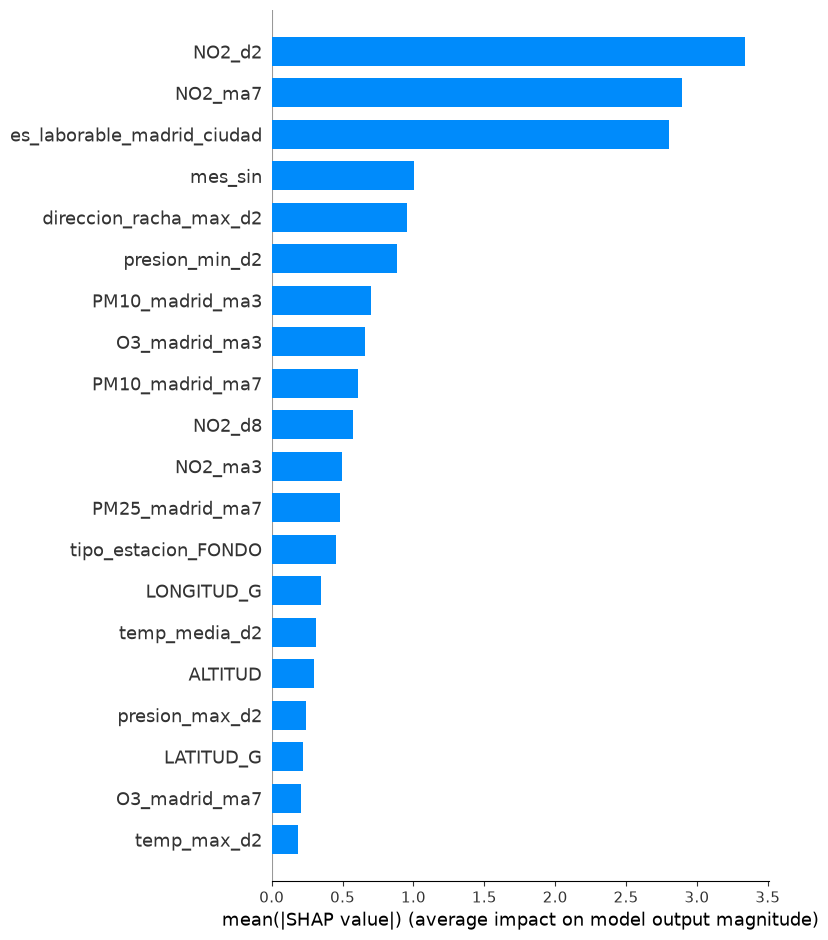

In [60]:
shap.summary_plot(
    shap_values,
    X_val,
    plot_type="bar",
    max_display=20
)

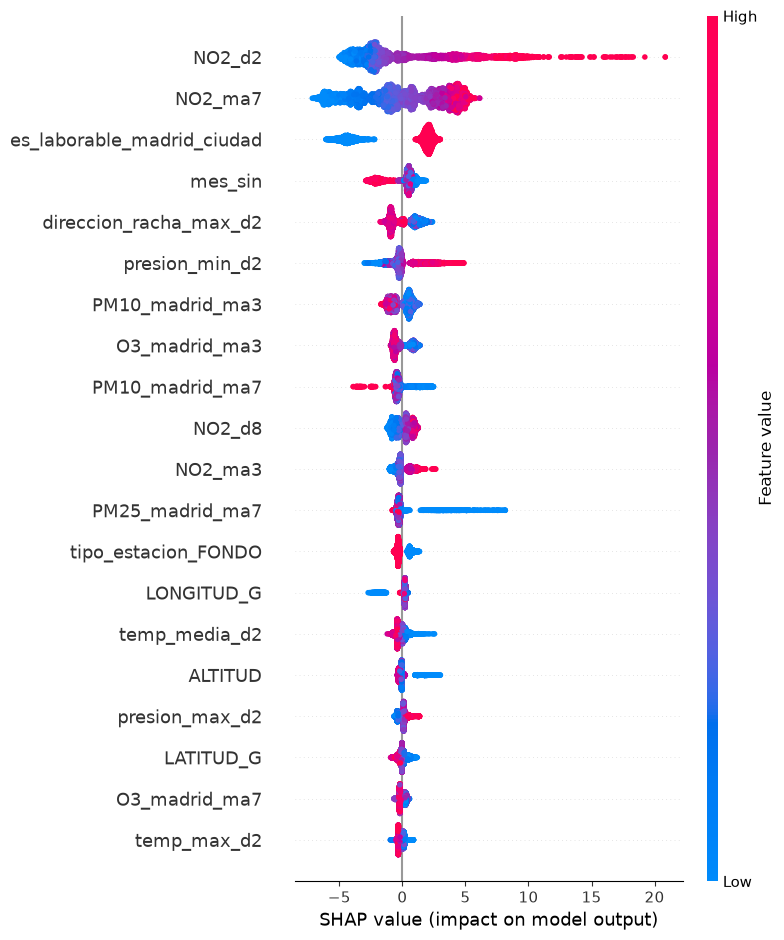

In [61]:
shap.summary_plot(
    shap_values,
    X_val,
    max_display=20
)

## 18. Estudio de ablación por bloques de variables

Para evaluar la contribución de las distintas fuentes de información se realiza un estudio de ablación sobre el conjunto de validación de 2023.

Partiendo del histórico reciente de NO₂, se incorporan progresivamente los bloques de variables de calendario, meteorología, contexto de otros contaminantes y características espaciales de las estaciones.

Todos los modelos utilizan la misma configuración de hiperparámetros seleccionada previamente. De esta forma, las diferencias de rendimiento pueden atribuirse principalmente a la información incorporada y no a cambios en la configuración del algoritmo.

El conjunto de test de 2024 permanece excluido de este análisis.

In [63]:
# ============================================================
# BLOQUES DE FEATURES PARA EL ESTUDIO DE ABLACIÓN
# ============================================================

features_no2 = [
    "NO2_d2",
    "NO2_d3",
    "NO2_d8",
    "NO2_ma3",
    "NO2_ma7"
]

features_calendario = [
    "es_laborable_madrid_ciudad",
    "mes_sin",
    "mes_cos"
]

features_contexto = [
    c for c in features
    if c.startswith(("O3_madrid_", "PM10_madrid_", "PM25_madrid_"))
]

features_meteo = [
    c for c in features
    if c.endswith("_d2")
    and c not in features_no2
    and c not in features_contexto
]

features_estacion = [
    "LATITUD_G",
    "LONGITUD_G",
    "ALTITUD",
    "tipo_estacion_FONDO",
    "tipo_estacion_TRAFICO"
]

print("Histórico NO2:", len(features_no2))
print("Calendario:", len(features_calendario))
print("Meteorología:", len(features_meteo))
print("Contexto contaminantes:", len(features_contexto))
print("Estación:", len(features_estacion))

print("\nTOTAL:", sum([
    len(features_no2),
    len(features_calendario),
    len(features_meteo),
    len(features_contexto),
    len(features_estacion)
]))

Histórico NO2: 5
Calendario: 3
Meteorología: 13
Contexto contaminantes: 15
Estación: 5

TOTAL: 41


In [65]:
bloques_ablacion = {
    "Histórico NO2":
        features_no2,

    "NO2 + calendario":
        features_no2
        + features_calendario,

    "NO2 + calendario + meteo":
        features_no2
        + features_calendario
        + features_meteo,

    "NO2 + calendario + meteo + contexto":
        features_no2
        + features_calendario
        + features_meteo
        + features_contexto,

    "Modelo completo":
        features_no2
        + features_calendario
        + features_meteo
        + features_contexto
        + features_estacion
}

for nombre, cols in bloques_ablacion.items():
    print(f"{nombre}: {len(cols)} features")

Histórico NO2: 5 features
NO2 + calendario: 8 features
NO2 + calendario + meteo: 21 features
NO2 + calendario + meteo + contexto: 36 features
Modelo completo: 41 features


In [66]:
# ============================================================
# ESTUDIO DE ABLACIÓN - VALIDATION 2023
# ============================================================

resultados_ablacion = []

for nombre, cols in bloques_ablacion.items():

    modelo_ab = XGBRegressor(
        **mejores_params,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    modelo_ab.fit(
        X_train[cols],
        y_train
    )

    pred_ab = modelo_ab.predict(
        X_val[cols]
    )

    mae = mean_absolute_error(y_val, pred_ab)
    rmse = np.sqrt(mean_squared_error(y_val, pred_ab))
    r2 = r2_score(y_val, pred_ab)
    bias = np.mean(pred_ab - y_val.values)

    resultados_ablacion.append({
        "Modelo": nombre,
        "N_features": len(cols),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Bias": bias
    })

In [67]:
# ============================================================
# TABLA COMPARATIVA
# ============================================================

fila_persistencia = pd.DataFrame([{
    "Modelo": "Persistencia D-2",
    "N_features": 1,
    "MAE": mae_persistencia,
    "RMSE": rmse_persistencia,
    "R2": r2_persistencia,
    "Bias": bias_persistencia
}])

tabla_ablacion = pd.concat(
    [
        fila_persistencia,
        pd.DataFrame(resultados_ablacion)
    ],
    ignore_index=True
)

display(tabla_ablacion.round(3))

,Modelo,N_features,MAE,RMSE,R2,Bias
0,Persistencia D-2,1,10.568,14.206,0.167,-0.006
1,Histórico NO2,5,9.240,12.061,0.399,-0.010
2,NO2 + calendario,8,8.846,11.611,0.443,-0.062
3,NO2 + calendario + meteo,21,8.626,11.306,0.472,0.139
4,NO2 + calendario + meteo + contexto,36,8.543,11.108,0.490,-0.103
5,Modelo completo,41,8.475,11.040,0.497,-0.096


In [68]:
# ============================================================
# PARÁMETROS DEFINITIVOS SELECCIONADOS EN VALIDACIÓN
# ============================================================

param_names = [
    "n_estimators",
    "learning_rate",
    "max_depth",
    "min_child_weight",
    "subsample",
    "colsample_bytree",
    "reg_alpha",
    "reg_lambda"
]

params_finales = {
    p: mejor_fino[p]
    for p in param_names
}

# Algunos valores procedentes del DataFrame pueden ser numpy types.
# Los convertimos a tipos nativos.
params_finales["n_estimators"] = int(params_finales["n_estimators"])
params_finales["max_depth"] = int(params_finales["max_depth"])

for p in [
    "learning_rate",
    "min_child_weight",
    "subsample",
    "colsample_bytree",
    "reg_alpha",
    "reg_lambda"
]:
    params_finales[p] = float(params_finales[p])

params_finales

{'n_estimators': 1000,
 'learning_rate': 0.0075,
 'max_depth': 3,
 'min_child_weight': 5.0,
 'subsample': 0.8,
 'colsample_bytree': 0.7,
 'reg_alpha': 1.0,
 'reg_lambda': 10.0}

In [69]:
modelo_final_val = XGBRegressor(
    **params_finales,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

modelo_final_val.fit(X_train, y_train)

pred_final_val = modelo_final_val.predict(X_val)

print("VALIDACIÓN 2023")
print("-" * 30)
print(f"MAE:  {mean_absolute_error(y_val, pred_final_val):.4f}")
print(
    f"RMSE: "
    f"{np.sqrt(mean_squared_error(y_val, pred_final_val)):.4f}"
)
print(f"R²:   {r2_score(y_val, pred_final_val):.4f}")

VALIDACIÓN 2023
------------------------------
MAE:  8.4606
RMSE: 11.0297
R²:   0.4976


## 19. Entrenamiento definitivo y evaluación sobre test

Una vez seleccionada la configuración final utilizando exclusivamente el conjunto de validación de 2023, se procede al entrenamiento definitivo del modelo.

Para ello, se combinan los datos de entrenamiento (2020–2022) y validación (2023), utilizando toda la información disponible hasta el final de 2023.

El modelo resultante se evalúa una única vez sobre el conjunto de test correspondiente a 2024, que no ha intervenido en ninguna etapa de selección de variables ni ajuste de hiperparámetros.

Esta evaluación constituye la estimación final de la capacidad de generalización temporal del modelo.

In [70]:
# ============================================================
# CONJUNTO FINAL DE ENTRENAMIENTO: 2020-2023
# ============================================================

train_final = pd.concat(
    [train, val],
    ignore_index=True
).sort_values(["fecha", "estacion"])

X_train_final = train_final[features].copy()
y_train_final = train_final[TARGET].copy()

print("Entrenamiento final")
print("-" * 35)
print(
    train_final["fecha"].min(),
    "→",
    train_final["fecha"].max()
)
print("X_train_final:", X_train_final.shape)
print("y_train_final:", y_train_final.shape)

print("\nTest final")
print("-" * 35)
print(
    test["fecha"].min(),
    "→",
    test["fecha"].max()
)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Entrenamiento final
-----------------------------------
2020-01-09 00:00:00 → 2023-12-31 00:00:00
X_train_final: (31966, 41)
y_train_final: (31966,)

Test final
-----------------------------------
2024-01-01 00:00:00 → 2024-12-31 00:00:00
X_test: (8052, 41)
y_test: (8052,)


In [71]:
# ============================================================
# MODELO DEFINITIVO
# ============================================================

modelo_final = XGBRegressor(
    **params_finales,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

modelo_final.fit(
    X_train_final,
    y_train_final
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [72]:
# ============================================================
# EVALUACIÓN FINAL - TEST 2024
# ============================================================

pred_test = modelo_final.predict(X_test)

mae_test = mean_absolute_error(y_test, pred_test)

rmse_test = np.sqrt(
    mean_squared_error(y_test, pred_test)
)

r2_test = r2_score(y_test, pred_test)

bias_test = np.mean(
    pred_test - y_test.values
)

print("RESULTADOS FINALES - TEST 2024")
print("-" * 40)
print(f"MAE:  {mae_test:.3f}")
print(f"RMSE: {rmse_test:.3f}")
print(f"R²:   {r2_test:.3f}")
print(f"Bias: {bias_test:.3f}")

RESULTADOS FINALES - TEST 2024
----------------------------------------
MAE:  8.012
RMSE: 10.141
R²:   0.457
Bias: 2.435


In [73]:
# ============================================================
# PERSISTENCIA D-2 - TEST 2024
# ============================================================

pred_persistencia_test = X_test["NO2_d2"].values

mae_persistencia_test = mean_absolute_error(
    y_test,
    pred_persistencia_test
)

rmse_persistencia_test = np.sqrt(
    mean_squared_error(
        y_test,
        pred_persistencia_test
    )
)

r2_persistencia_test = r2_score(
    y_test,
    pred_persistencia_test
)

bias_persistencia_test = np.mean(
    pred_persistencia_test - y_test.values
)

print("PERSISTENCIA D-2 - TEST 2024")
print("-" * 40)
print(f"MAE:  {mae_persistencia_test:.3f}")
print(f"RMSE: {rmse_persistencia_test:.3f}")
print(f"R²:   {r2_persistencia_test:.3f}")
print(f"Bias: {bias_persistencia_test:.3f}")

PERSISTENCIA D-2 - TEST 2024
----------------------------------------
MAE:  9.403
RMSE: 12.454
R²:   0.181
Bias: -0.025


In [74]:
# ============================================================
# DIAGNÓSTICO DEL BIAS EN TEST 2024
# ============================================================

print("Media NO2 real por año")
print(
    df_modelo_limpio
    .groupby(df_modelo_limpio["fecha"].dt.year)["NO2"]
    .mean()
    .round(3)
)

print("\nTEST 2024")
print("-" * 35)
print(f"NO2 real medio:      {y_test.mean():.3f}")
print(f"NO2 predicho medio:  {pred_test.mean():.3f}")
print(f"Diferencia:           {pred_test.mean() - y_test.mean():.3f}")

Media NO2 real por año
fecha
2020    26.086
2021    28.755
2022    28.125
2023    27.458
2024    22.969
Name: NO2, dtype: float64

TEST 2024
-----------------------------------
NO2 real medio:      22.969
NO2 predicho medio:  25.404
Diferencia:           2.435


### Análisis del sesgo temporal en el conjunto de test

La evaluación sobre 2024 muestra un **MAE de 8.012 µg/m³**, un **RMSE de 10.141 µg/m³** y un **R² de 0.457**. Frente al modelo de persistencia D−2, cuyo MAE es de 9.403 µg/m³, XGBoost reduce el error absoluto medio aproximadamente un **14.8 %**.

Sin embargo, se observa un **bias positivo de 2.435 µg/m³**, indicando una tendencia global del modelo a sobreestimar las concentraciones de NO₂ durante 2024.

El análisis de la concentración media anual muestra que 2024 presenta un nivel medio de NO₂ (22.969 µg/m³) sensiblemente inferior al observado durante el periodo utilizado para el entrenamiento del modelo. En particular, la media de 2023 fue de 27.458 µg/m³.

El análisis mensual muestra además que esta sobreestimación no se concentra en un único periodo, sino que aparece en 11 de los 12 meses del año. Estos resultados sugieren la existencia de un cambio temporal en la distribución de la variable objetivo que el modelo, entrenado con datos de 2020–2023, no captura completamente.

No se realiza ninguna corrección del sesgo utilizando información de 2024, ya que ello supondría utilizar el conjunto de test para modificar el modelo y comprometería la independencia de la evaluación final.

In [75]:
diagnostico_2024 = test[
    ["fecha", "estacion", "NO2"]
].copy()

diagnostico_2024["prediccion"] = pred_test
diagnostico_2024["error"] = (
    diagnostico_2024["prediccion"]
    - diagnostico_2024["NO2"]
)

diagnostico_mensual = (
    diagnostico_2024
    .assign(mes=lambda x: x["fecha"].dt.month)
    .groupby("mes")
    .agg(
        NO2_real=("NO2", "mean"),
        NO2_predicho=("prediccion", "mean"),
        bias=("error", "mean")
    )
)

display(diagnostico_mensual.round(3))

,NO2_real,NO2_predicho,bias
mes,,,
1,35.407,35.834000,0.427
2,29.351,33.654999,4.303
3,21.910,24.761000,2.851
4,19.929,22.062000,2.133
5,14.791,20.709999,5.920
6,14.853,18.084000,3.231
7,16.617,17.945000,1.327
8,15.043,17.148001,2.105
9,17.457,19.204000,1.746


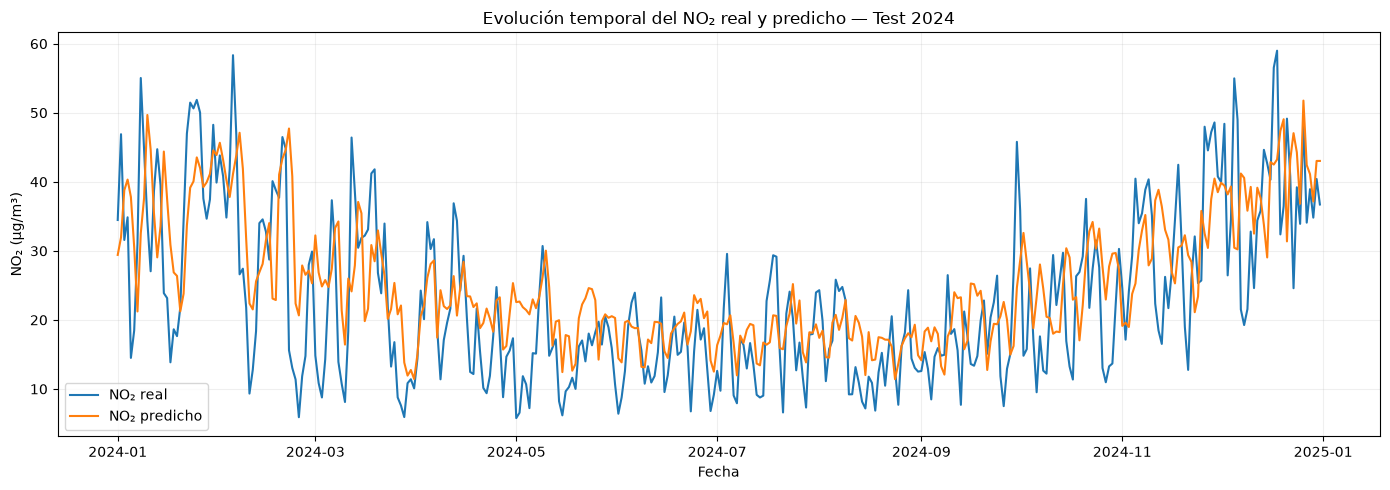

In [77]:
import matplotlib.pyplot as plt

# ============================================================
# EVOLUCIÓN TEMPORAL - TEST 2024
# ============================================================

serie_2024 = (
    diagnostico_2024
    .groupby("fecha")
    .agg(
        NO2_real=("NO2", "mean"),
        NO2_predicho=("prediccion", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(14, 5))

plt.plot(
    serie_2024["fecha"],
    serie_2024["NO2_real"],
    label="NO₂ real",
    linewidth=1.5
)

plt.plot(
    serie_2024["fecha"],
    serie_2024["NO2_predicho"],
    label="NO₂ predicho",
    linewidth=1.5
)

plt.xlabel("Fecha")
plt.ylabel("NO₂ (µg/m³)")
plt.title("Evolución temporal del NO₂ real y predicho — Test 2024")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Interpretación de la evolución temporal

La comparación entre las concentraciones medias diarias observadas y predichas muestra que el modelo reproduce adecuadamente la dinámica estacional general del NO₂ durante 2024. Se identifican concentraciones más elevadas durante los meses de invierno y al final del año, mientras que durante primavera y verano los niveles son considerablemente inferiores.

No obstante, las predicciones presentan una variabilidad menor que las observaciones reales. El modelo reproduce la tendencia general, pero suaviza algunos de los máximos y mínimos diarios más pronunciados. Este comportamiento es coherente con el horizonte predictivo planteado, ya que la información más reciente disponible para realizar la predicción corresponde a D−2.

Asimismo, durante buena parte de los meses de primavera y verano se observa una tendencia a situar las predicciones por encima de los valores reales. Este comportamiento es consistente con el bias positivo obtenido en el conjunto de test (+2.435 µg/m³) y con el descenso del nivel medio de NO₂ observado en 2024 respecto al periodo de entrenamiento.

## 20. Resumen de resultados del modelo de NO₂

La siguiente tabla resume el rendimiento final del modelo XGBoost y su comparación con el modelo de persistencia D−2.

La configuración de XGBoost fue seleccionada exclusivamente utilizando el conjunto de validación de 2023. Posteriormente, el modelo se reentrenó utilizando los datos disponibles entre 2020 y 2023 y se evaluó una única vez sobre el conjunto de test de 2024.

In [78]:
# ============================================================
# RESUMEN FINAL - TEST 2024
# ============================================================

resultados_finales = pd.DataFrame({
    "Modelo": [
        "Persistencia D-2",
        "XGBoost"
    ],
    "MAE": [
        mae_persistencia_test,
        mae_test
    ],
    "RMSE": [
        rmse_persistencia_test,
        rmse_test
    ],
    "R2": [
        r2_persistencia_test,
        r2_test
    ],
    "Bias": [
        bias_persistencia_test,
        bias_test
    ]
})

display(resultados_finales.round(3))

mejora_mae = (
    (mae_persistencia_test - mae_test)
    / mae_persistencia_test
    * 100
)

mejora_rmse = (
    (rmse_persistencia_test - rmse_test)
    / rmse_persistencia_test
    * 100
)

print(f"Reducción del MAE frente a persistencia:  {mejora_mae:.2f}%")
print(f"Reducción del RMSE frente a persistencia: {mejora_rmse:.2f}%")

,Modelo,MAE,RMSE,R2,Bias
0,Persistencia D-2,9.403,12.454,0.181,-0.025
1,XGBoost,8.012,10.141,0.457,2.435


Reducción del MAE frente a persistencia:  14.79%
Reducción del RMSE frente a persistencia: 18.57%


## 21. Conclusiones del modelo de NO₂

El modelo XGBoost desarrollado permite predecir la concentración diaria de NO₂ para cada estación bajo un escenario temporal conservador, en el que la información observada más reciente disponible corresponde a D−2.

La configuración final fue seleccionada utilizando exclusivamente el conjunto de validación de 2023 y posteriormente reentrenada con los datos de 2020–2023. La evaluación final sobre 2024 obtuvo un **MAE de 8.012 µg/m³**, un **RMSE de 10.141 µg/m³** y un **R² de 0.457**.

Frente al modelo de persistencia D−2, XGBoost consigue reducir el **MAE un 14.79 %** y el **RMSE un 18.57 %**, mostrando que la incorporación conjunta del histórico de contaminación, calendario, meteorología, contexto de otros contaminantes y características de las estaciones aporta capacidad predictiva adicional.

El estudio de ablación confirma esta conclusión. Partiendo de un MAE de 10.568 µg/m³ para la persistencia en validación, la incorporación del histórico de NO₂ reduce el error a 9.240 µg/m³. Posteriormente, la incorporación progresiva de calendario, meteorología, contexto de otros contaminantes y características de estación continúa mejorando el rendimiento hasta alcanzar aproximadamente 8.46 µg/m³ con el modelo completo.

El análisis SHAP muestra que las variables con mayor influencia sobre las predicciones son **NO2_d2**, **NO2_ma7** y **es_laborable_madrid_ciudad**. También presentan una contribución relevante variables meteorológicas y el contexto reciente de PM10, O₃ y PM2.5, respaldando la utilización de múltiples fuentes de información.

En el conjunto de test se observa un **bias positivo de 2.435 µg/m³**. La concentración media real de NO₂ disminuye hasta 22.969 µg/m³ en 2024, frente a 27.458 µg/m³ en 2023, mientras que el modelo predice una media de 25.404 µg/m³. Esto indica que el modelo no captura completamente el descenso del nivel basal observado en 2024 y tiende a sobreestimar las concentraciones durante gran parte del año.

Finalmente, la evolución temporal muestra que el modelo reproduce adecuadamente el patrón estacional general, aunque suaviza algunos de los máximos y mínimos diarios. Este comportamiento es consistente con la dificultad del horizonte predictivo considerado, dado que no se dispone de información observada de D−1 ni del propio día objetivo.

En conjunto, los resultados muestran que XGBoost mejora de forma consistente el benchmark de persistencia bajo las restricciones temporales establecidas, aunque persisten limitaciones relacionadas con cambios interanuales en la distribución del NO₂ y con la predicción de variaciones diarias extremas.